# Plotting rate RNN energy landscape

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys
import pickle as pk
from sklearn.decomposition import PCA
import torch

sys.path.append('/home/nuttidalab/Documents/spikeRNN/rate/')
# import model
from model import generate_input_stim_xor, eval_tf

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import vis_utils as vu
import trajectory_utils as tu
import importlib

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/trajectory/fixed_pt/')
import load_RNN_model as lrm
from run_RNN_search import get_period_pca

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/fixed-point-finder')
from FixedPointFinderTorch import FixedPointFinderTorch as FixedPointFinder
from plot_utils import plot_fps # in fixedpointfinder folder

/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(
2025-02-28 16:11:42.595288: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-28 16:11:42.603586: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-28 16:11:42.612605: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register facto

Instructions for updating:
non-resource variables are not supported in the long term


## Good model

In [2]:
models_type = 'good_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [3]:
RNN_model_file = model_list[0] # just grab the first model
model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'

print(f'Loading model: {RNN_model_file}')
rnn_path = os.path.join(models_dir, RNN_model_file) 
model = lrm.load_RNN_model(rnn_path)

settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 50, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

if not os.path.exists(f'{model_results_dir}delay{settings["delay"]}_synX.npy'):
        print('Generating synX')
        xx_trials, trial_stim_labels = tu.generate_synX(rnn_path, settings, 
                                save=1, model_results_dir = model_results_dir)
else:
        print('Loading synX')
        xx_trials = np.load(f'{model_results_dir}delay{settings["delay"]}_synX.npy')
        trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels.npy')

stim_on = settings['stim_on']
stim_dur = settings['stim_dur']
delay=settings['delay']
T = settings['T']

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659.mat
Loading synX


In [4]:
rnn_data = scipy.io.loadmat(models_dir + RNN_model_file)
rnn_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'N', 'abc', 'activation', 'all_perfs', 'b_out', 'curr_mod', 'eval_labels', 'eval_loss_mean', 'eval_os', 'eval_perf_mean', 'exc', 'inh', 'losses', 'm', 'model_path', 'o', 'opt_scaling_factor', 'r', 'r0', 'scaling_factors', 'som_N', 'som_m', 'stability', 'stable_mods2', 'stable_outs', 'stable_perfs', 'stable_trials', 'target', 'task_path5', 'tau', 'taus', 'taus_gaus', 'taus_gaus0', 'tr', 'u', 'w', 'w0', 'w_in', 'w_in0', 'w_out', 'x', 'x0', 'auto_N', 'auto_N_fr', 'auto_c', 'mean_decay', 'new_auto_c', 'outs', 'syn_decay', 'taus_decay_ms', 'trial_spks', 'use_this_W', 'pref_stim'])

In [5]:
# Loading model parameters
taus_gaus = torch.tensor(rnn_data['taus_gaus'])
taus = torch.tensor(rnn_data['taus'][0])
w = torch.tensor(rnn_data['w'])
m = torch.tensor(rnn_data['m'])
w_in = torch.tensor(rnn_data['w_in'])
taus_sig = torch.sigmoid(taus_gaus)*(taus[1] - taus[0]) + taus[0] # Neural time constant
ww = torch.matmul(w, m) # Recurrent weight matrix

In [6]:
# Plot energy landscape figures
# Creating a 2d grid over PC space to plot different qs
nComponents = 2
pca_period = get_period_pca(xx_trials,'delay',nComponents)

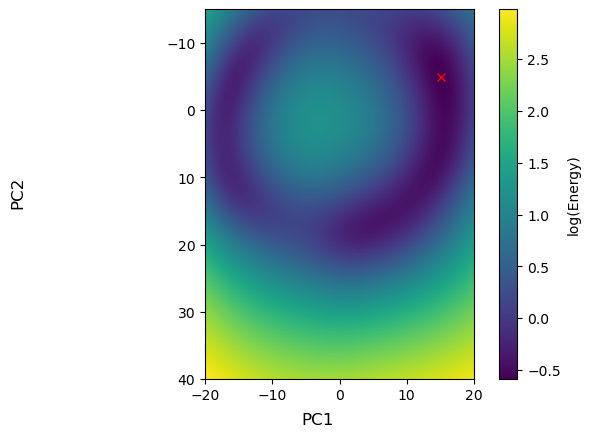

In [7]:
# PC space grid 
importlib.reload(tu)

res = 100

xVec = np.linspace(-20,20,res)
yVec = np.linspace(-15,40,res)

# am i plotting an energy landscape for each stim +1/-1? 
# stim_cases = [stim_null,stim_task,stim_anti_task]
# stim_names = ['null','task','anti_task']
# vmin,vmax = 1.5,7

# fig, axs = plt.subplots(1, len(stim_cases),sharey=True)
# for plotI, u in enumerate(stim_cases):    
fig, axs = plt.subplots(1,1,sharey=True)

u = np.array([0,0]).T.astype('float32')  # no stim in delay
u = torch.tensor(u, dtype=torch.float32)
qMatrix = np.zeros((res,res))            
for i in np.arange(res):
    for j in np.arange(res):
        x_real = torch.tensor(pca_period.inverse_transform([xVec[i],yVec[j]]))
        qMatrix[i,j] = tu.q_fun(x_real, taus_sig, ww, w_in, u)
# Getting minimum energy point    
min_idx = np.unravel_index(np.argmin(qMatrix),qMatrix.shape)
#plt.imshow(np.log(qMatrix), extent=[xVec[0],xVec[-1],yVec[0],yVec[-1]])
im = axs.imshow(np.log(qMatrix).T, extent=[xVec[0],xVec[-1],yVec[-1],yVec[0]])#, vmin=vmin, vmax=vmax)
axs.plot(xVec[min_idx[0]],yVec[min_idx[1]],'rx')
# axs[plotI].set_title('input='+stim_names[plotI])

# for plotI, u in enumerate([0]): # FIX THE U HERE TO BE STIM
#     u = torch.tensor(u)
#     qMatrix = np.zeros((res,res))            
#     for i in np.arange(res):
#         for j in np.arange(res):
#             x_real = torch.tensor(pca_period.inverse_transform([xVec[i],yVec[j]]))
#             qMatrix[i,j] = tu.q_fun(x_real, taus_sig, ww, w_in, u)
#     # Getting minimum energy point    
#     min_idx = np.unravel_index(np.argmin(qMatrix),qMatrix.shape)
#     #plt.imshow(np.log(qMatrix), extent=[xVec[0],xVec[-1],yVec[0],yVec[-1]])
#     im = axs[plotI].imshow(np.log(qMatrix).T, extent=[xVec[0],xVec[-1],yVec[-1],yVec[0]], vmin=vmin, vmax=vmax)
#     axs[plotI].plot(xVec[min_idx[0]],yVec[min_idx[1]],'rx')
#     # axs[plotI].set_title('input='+stim_names[plotI])


#fig.colorbar(im, ax=axs.ravel().tolist())

# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
# divider = make_axes_locatable(axs[-1])
# cax = divider.append_axes("right", size="5%", pad=0.05)
   
# cbar=plt.colorbar(im, cax=cax)
cbar=plt.colorbar(im)
cbar.set_label('log(Energy)')

# common axis labels
fig.supxlabel('PC1')
fig.supylabel('PC2')

# if modality_type == 'instr':
#     modality_name = '1-mod/1-layer'
# elif modality_type == 'instr_two_layers':
#     modality_name = '1-mod/2-layers'
# elif modality_type == 'instr2':
#     modality_name = '2-mod/1-layer'

# fig.suptitle('Instruction energy landscape: '+modality_name)
#plt.title('Energy: u=task / PC period = instruction')
#cbar = plt.colorbar()
#cbar.set_label('log Energy')
# plt.savefig("local_figure_energy_landscape.png")
# plt.savefig(modality_type+"_energy_landscape.pdf")
plt.show()

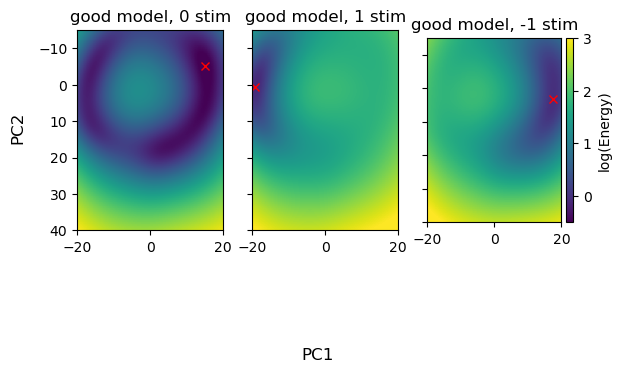

In [15]:
# PC space grid 
importlib.reload(tu)

res = 100

xVec = np.linspace(-20,20,res)
yVec = np.linspace(-15,40,res)
 
# fig, axs = plt.subplots(1,1,sharey=True)

stim_condns = [[0,0],[1,0],[-1,0]]
stim_names = ['no stim','+1','-1']

fig, axs = plt.subplots(1, len(stim_condns),sharey=True)
for plotI, u in enumerate(stim_condns):
    u = torch.tensor(u, dtype=torch.float32)
    qMatrix = np.zeros((res,res))            
    for i in np.arange(res):
        for j in np.arange(res):
            x_real = torch.tensor(pca_period.inverse_transform([xVec[i],yVec[j]]))
            qMatrix[i,j] = tu.q_fun(x_real, taus_sig, ww, w_in, u)
    # Getting minimum energy point    
    min_idx = np.unravel_index(np.argmin(qMatrix),qMatrix.shape)
    im = axs[plotI].imshow(np.log(qMatrix).T, extent=[xVec[0],xVec[-1],yVec[-1],yVec[0]], vmin=-0.5, vmax=3)
    axs[plotI].plot(xVec[min_idx[0]],yVec[min_idx[1]],'rx')
    axs[plotI].set_title(f'good model, {int(u[0])} stim')

# for plotI, u in enumerate([0]): # FIX THE U HERE TO BE STIM
#     u = torch.tensor(u)
#     qMatrix = np.zeros((res,res))            
#     for i in np.arange(res):
#         for j in np.arange(res):
#             x_real = torch.tensor(pca_period.inverse_transform([xVec[i],yVec[j]]))
#             qMatrix[i,j] = tu.q_fun(x_real, taus_sig, ww, w_in, u)
#     # Getting minimum energy point    
#     min_idx = np.unravel_index(np.argmin(qMatrix),qMatrix.shape)
#     #plt.imshow(np.log(qMatrix), extent=[xVec[0],xVec[-1],yVec[0],yVec[-1]])
#     im = axs[plotI].imshow(np.log(qMatrix).T, extent=[xVec[0],xVec[-1],yVec[-1],yVec[0]], vmin=vmin, vmax=vmax)
#     axs[plotI].plot(xVec[min_idx[0]],yVec[min_idx[1]],'rx')
#     # axs[plotI].set_title('input='+stim_names[plotI])


#fig.colorbar(im, ax=axs.ravel().tolist())

# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
divider = make_axes_locatable(axs[-1])
cax = divider.append_axes("right", size="5%", pad=0.05)
   
cbar=plt.colorbar(im, cax=cax)
# cbar=plt.colorbar(im)
cbar.set_label('log(Energy)')

# common axis labels
fig.supxlabel('PC1')
fig.supylabel('PC2')

# if modality_type == 'instr':
#     modality_name = '1-mod/1-layer'
# elif modality_type == 'instr_two_layers':
#     modality_name = '1-mod/2-layers'
# elif modality_type == 'instr2':
#     modality_name = '2-mod/1-layer'

# fig.suptitle('Instruction energy landscape: '+modality_name)
#plt.title('Energy: u=task / PC period = instruction')
#cbar = plt.colorbar()
#cbar.set_label('log Energy')
# plt.savefig("local_figure_energy_landscape.png")
# plt.savefig(modality_type+"_energy_landscape.pdf")
plt.show()

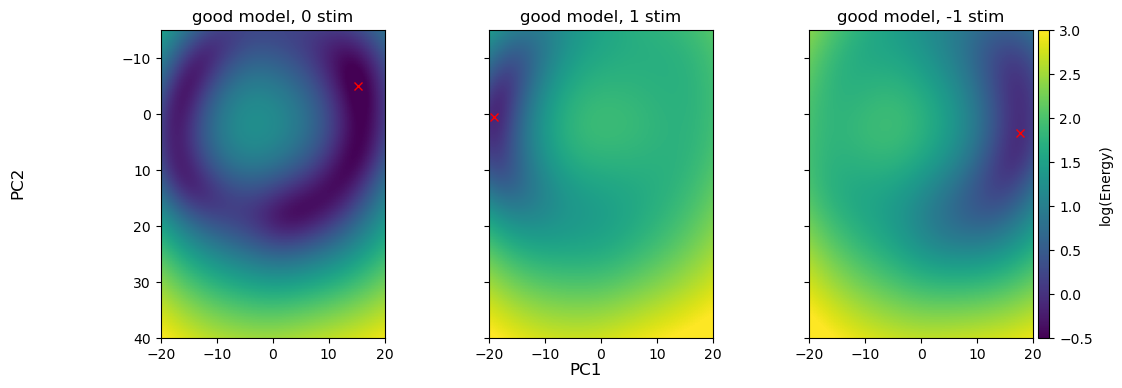

In [13]:
# PC space grid 
importlib.reload(tu)

res = 100

xVec = np.linspace(-20,20,res)
yVec = np.linspace(-15,40,res)

stim_condns = [[0,0],[1,0],[-1,0]]
stim_names = ['no stim','+1','-1']

fig, axs = plt.subplots(1, len(stim_condns),sharey=True, figsize=(12, 4),
                        gridspec_kw={'width_ratios': [1, 1, 1]})
for plotI, u in enumerate(stim_condns):
    u = torch.tensor(u, dtype=torch.float32)
    qMatrix = np.zeros((res,res))            
    for i in np.arange(res):
        for j in np.arange(res):
            x_real = torch.tensor(pca_period.inverse_transform([xVec[i],yVec[j]]))
            qMatrix[i,j] = tu.q_fun(x_real, taus_sig, ww, w_in, u)
    # Getting minimum energy point    
    min_idx = np.unravel_index(np.argmin(qMatrix),qMatrix.shape)
    im = axs[plotI].imshow(np.log(qMatrix).T, extent=[xVec[0],xVec[-1],yVec[-1],yVec[0]], vmin=-0.5, vmax=3)
    axs[plotI].plot(xVec[min_idx[0]],yVec[min_idx[1]],'rx')
    axs[plotI].set_title(f'good model, {int(u[0])} stim')

#fig.colorbar(im, ax=axs.ravel().tolist())

# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
divider = make_axes_locatable(axs[-1])
# cax = divider.append_axes("right", size="5%", pad=0.05)
cax = divider.append_axes("right", size="5%", pad=0.05)
   
cbar=plt.colorbar(im, cax=cax)
# cbar=plt.colorbar(im)
cbar.set_label('log(Energy)')

# common axis labels
fig.supxlabel('PC1')
fig.supylabel('PC2')

# plt.savefig("local_figure_energy_landscape.png")
# plt.savefig(modality_type+"_energy_landscape.pdf")
plt.subplots_adjust(right=0.9)
plt.show()

## Bad model

In [2]:
models_type = 'bad_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [3]:
RNN_model_file = model_list[0] # just grab the first model
model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'

print(f'Loading model: {RNN_model_file}')
rnn_path = os.path.join(models_dir, RNN_model_file) 
model = lrm.load_RNN_model(rnn_path)

settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 50, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

if not os.path.exists(f'{model_results_dir}delay{settings["delay"]}_synX.npy'):
        print('Generating synX')
        xx_trials, trial_stim_labels = tu.generate_synX(rnn_path, settings, 
                                save=1, model_results_dir = model_results_dir)
else:
        print('Loading synX')
        xx_trials = np.load(f'{model_results_dir}delay{settings["delay"]}_synX.npy')
        trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels.npy')

stim_on = settings['stim_on']
stim_dur = settings['stim_dur']
delay=settings['delay']
T = settings['T']

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906.mat
Loading synX


In [4]:
rnn_data = scipy.io.loadmat(models_dir + RNN_model_file)
rnn_data.keys()

dict_keys(['__header__', '__version__', '__globals__', 'N', 'abc', 'activation', 'all_perfs', 'b_out', 'curr_mod', 'eval_labels', 'eval_loss_mean', 'eval_os', 'eval_perf_mean', 'exc', 'inh', 'losses', 'm', 'model_path', 'o', 'opt_scaling_factor', 'r', 'r0', 'scaling_factors', 'som_N', 'som_m', 'stability', 'stable_mods2', 'stable_outs', 'stable_perfs', 'stable_trials', 'target', 'task_path5', 'tau', 'taus', 'taus_gaus', 'taus_gaus0', 'tr', 'u', 'w', 'w0', 'w_in', 'w_in0', 'w_out', 'x', 'x0', 'auto_N', 'auto_N_fr', 'auto_c', 'mean_decay', 'new_auto_c', 'outs', 'syn_decay', 'taus_decay_ms', 'trial_spks', 'use_this_W'])

In [5]:
# Loading model parameters
taus_gaus = torch.tensor(rnn_data['taus_gaus'])
taus = torch.tensor(rnn_data['taus'][0])
w = torch.tensor(rnn_data['w'])
m = torch.tensor(rnn_data['m'])
w_in = torch.tensor(rnn_data['w_in'])
taus_sig = torch.sigmoid(taus_gaus)*(taus[1] - taus[0]) + taus[0] # Neural time constant
ww = torch.matmul(w, m) # Recurrent weight matrix

In [6]:
# Plot energy landscape figures
# Creating a 2d grid over PC space to plot different qs
nComponents = 2
pca_period = get_period_pca(xx_trials,'delay',nComponents)

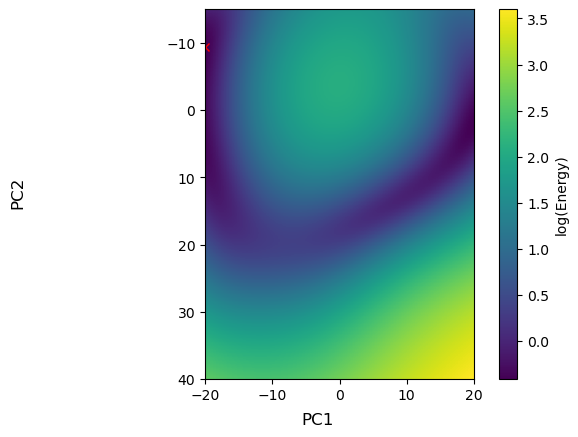

In [7]:
# PC space grid 
importlib.reload(tu)

res = 100

xVec = np.linspace(-20,20,res)
yVec = np.linspace(-15,40,res)

# am i plotting an energy landscape for each stim +1/-1? 
# stim_cases = [stim_null,stim_task,stim_anti_task]
# stim_names = ['null','task','anti_task']
# vmin,vmax = 1.5,7

# fig, axs = plt.subplots(1, len(stim_cases),sharey=True)
# for plotI, u in enumerate(stim_cases):    
fig, axs = plt.subplots(1,1,sharey=True)

u = np.array([0,0]).T.astype('float32')  # no stim in delay
u = torch.tensor(u, dtype=torch.float32)
qMatrix = np.zeros((res,res))            
for i in np.arange(res):
    for j in np.arange(res):
        x_real = torch.tensor(pca_period.inverse_transform([xVec[i],yVec[j]]))
        qMatrix[i,j] = tu.q_fun(x_real, taus_sig, ww, w_in, u)
# Getting minimum energy point    
min_idx = np.unravel_index(np.argmin(qMatrix),qMatrix.shape)
#plt.imshow(np.log(qMatrix), extent=[xVec[0],xVec[-1],yVec[0],yVec[-1]])
im = axs.imshow(np.log(qMatrix).T, extent=[xVec[0],xVec[-1],yVec[-1],yVec[0]])#, vmin=vmin, vmax=vmax)
axs.plot(xVec[min_idx[0]],yVec[min_idx[1]],'rx')
# axs[plotI].set_title('input='+stim_names[plotI])

# for plotI, u in enumerate([0]): # FIX THE U HERE TO BE STIM
#     u = torch.tensor(u)
#     qMatrix = np.zeros((res,res))            
#     for i in np.arange(res):
#         for j in np.arange(res):
#             x_real = torch.tensor(pca_period.inverse_transform([xVec[i],yVec[j]]))
#             qMatrix[i,j] = tu.q_fun(x_real, taus_sig, ww, w_in, u)
#     # Getting minimum energy point    
#     min_idx = np.unravel_index(np.argmin(qMatrix),qMatrix.shape)
#     #plt.imshow(np.log(qMatrix), extent=[xVec[0],xVec[-1],yVec[0],yVec[-1]])
#     im = axs[plotI].imshow(np.log(qMatrix).T, extent=[xVec[0],xVec[-1],yVec[-1],yVec[0]], vmin=vmin, vmax=vmax)
#     axs[plotI].plot(xVec[min_idx[0]],yVec[min_idx[1]],'rx')
#     # axs[plotI].set_title('input='+stim_names[plotI])


#fig.colorbar(im, ax=axs.ravel().tolist())

# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
# divider = make_axes_locatable(axs[-1])
# cax = divider.append_axes("right", size="5%", pad=0.05)
   
# cbar=plt.colorbar(im, cax=cax)
cbar=plt.colorbar(im)
cbar.set_label('log(Energy)')

# common axis labels
fig.supxlabel('PC1')
fig.supylabel('PC2')

# if modality_type == 'instr':
#     modality_name = '1-mod/1-layer'
# elif modality_type == 'instr_two_layers':
#     modality_name = '1-mod/2-layers'
# elif modality_type == 'instr2':
#     modality_name = '2-mod/1-layer'

# fig.suptitle('Instruction energy landscape: '+modality_name)
#plt.title('Energy: u=task / PC period = instruction')
#cbar = plt.colorbar()
#cbar.set_label('log Energy')
# plt.savefig("local_figure_energy_landscape.png")
# plt.savefig(modality_type+"_energy_landscape.pdf")
plt.show()

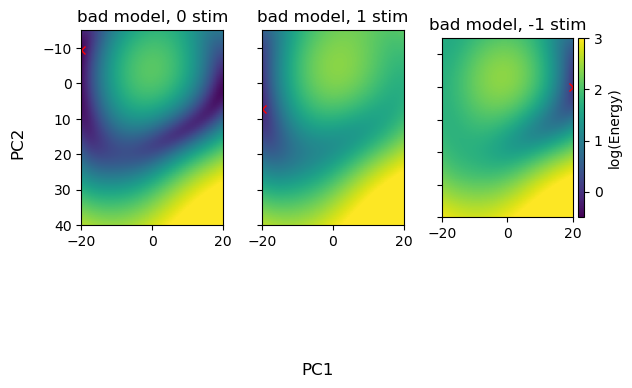

In [9]:
# PC space grid 
importlib.reload(tu)

res = 100

xVec = np.linspace(-20,20,res)
yVec = np.linspace(-15,40,res)
 
# fig, axs = plt.subplots(1,1,sharey=True)

stim_condns = [[0,0],[1,0],[-1,0]]
stim_names = ['no stim','+1','-1']

fig, axs = plt.subplots(1, len(stim_condns),sharey=True)
for plotI, u in enumerate(stim_condns):
    u = torch.tensor(u, dtype=torch.float32)
    qMatrix = np.zeros((res,res))            
    for i in np.arange(res):
        for j in np.arange(res):
            x_real = torch.tensor(pca_period.inverse_transform([xVec[i],yVec[j]]))
            qMatrix[i,j] = tu.q_fun(x_real, taus_sig, ww, w_in, u)
    # Getting minimum energy point    
    min_idx = np.unravel_index(np.argmin(qMatrix),qMatrix.shape)
    im = axs[plotI].imshow(np.log(qMatrix).T, extent=[xVec[0],xVec[-1],yVec[-1],yVec[0]], vmin=-0.5, vmax=3)
    axs[plotI].plot(xVec[min_idx[0]],yVec[min_idx[1]],'rx')
    axs[plotI].set_title(f'bad model, {int(u[0])} stim')

# for plotI, u in enumerate([0]): # FIX THE U HERE TO BE STIM
#     u = torch.tensor(u)
#     qMatrix = np.zeros((res,res))            
#     for i in np.arange(res):
#         for j in np.arange(res):
#             x_real = torch.tensor(pca_period.inverse_transform([xVec[i],yVec[j]]))
#             qMatrix[i,j] = tu.q_fun(x_real, taus_sig, ww, w_in, u)
#     # Getting minimum energy point    
#     min_idx = np.unravel_index(np.argmin(qMatrix),qMatrix.shape)
#     #plt.imshow(np.log(qMatrix), extent=[xVec[0],xVec[-1],yVec[0],yVec[-1]])
#     im = axs[plotI].imshow(np.log(qMatrix).T, extent=[xVec[0],xVec[-1],yVec[-1],yVec[0]], vmin=vmin, vmax=vmax)
#     axs[plotI].plot(xVec[min_idx[0]],yVec[min_idx[1]],'rx')
#     # axs[plotI].set_title('input='+stim_names[plotI])


#fig.colorbar(im, ax=axs.ravel().tolist())

# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
divider = make_axes_locatable(axs[-1])
cax = divider.append_axes("right", size="5%", pad=0.05)
   
cbar=plt.colorbar(im, cax=cax)
# cbar=plt.colorbar(im)
cbar.set_label('log(Energy)')

# common axis labels
fig.supxlabel('PC1')
fig.supylabel('PC2')

# if modality_type == 'instr':
#     modality_name = '1-mod/1-layer'
# elif modality_type == 'instr_two_layers':
#     modality_name = '1-mod/2-layers'
# elif modality_type == 'instr2':
#     modality_name = '2-mod/1-layer'

# fig.suptitle('Instruction energy landscape: '+modality_name)
#plt.title('Energy: u=task / PC period = instruction')
#cbar = plt.colorbar()
#cbar.set_label('log Energy')
# plt.savefig("local_figure_energy_landscape.png")
# plt.savefig(modality_type+"_energy_landscape.pdf")
plt.tight_layout()
plt.show()

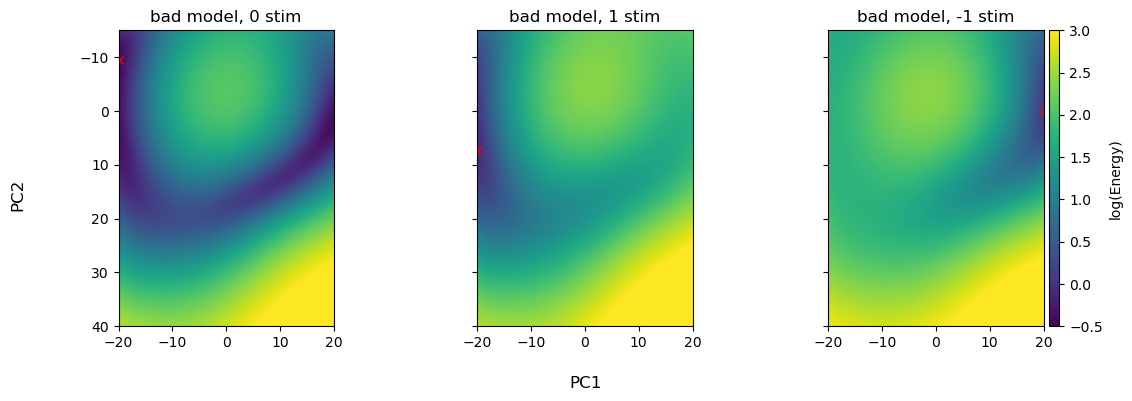

In [7]:
# PC space grid 
importlib.reload(tu)

res = 100

xVec = np.linspace(-20,20,res)
yVec = np.linspace(-15,40,res)
 
# fig, axs = plt.subplots(1,1,sharey=True)

stim_condns = [[0,0],[1,0],[-1,0]]
stim_names = ['no stim','+1','-1']

fig, axs = plt.subplots(1, len(stim_condns),sharey=True,
                        figsize=(12, 4),
                        gridspec_kw={'width_ratios': [1, 1, 1]})
for plotI, u in enumerate(stim_condns):
    u = torch.tensor(u, dtype=torch.float32)
    qMatrix = np.zeros((res,res))            
    for i in np.arange(res):
        for j in np.arange(res):
            x_real = torch.tensor(pca_period.inverse_transform([xVec[i],yVec[j]]))
            qMatrix[i,j] = tu.q_fun(x_real, taus_sig, ww, w_in, u)
    # Getting minimum energy point    
    min_idx = np.unravel_index(np.argmin(qMatrix),qMatrix.shape)
    im = axs[plotI].imshow(np.log(qMatrix).T, extent=[xVec[0],xVec[-1],yVec[-1],yVec[0]], vmin=-0.5, vmax=3)
    axs[plotI].plot(xVec[min_idx[0]],yVec[min_idx[1]],'rx')
    axs[plotI].set_title(f'bad model, {int(u[0])} stim')

# create an axes on the right side of ax. The width of cax will be 5%
# of ax and the padding between cax and ax will be fixed at 0.05 inch.
divider = make_axes_locatable(axs[-1])
cax = divider.append_axes("right", size="5%", pad=0.05)
   
cbar=plt.colorbar(im, cax=cax)
# cbar=plt.colorbar(im)
cbar.set_label('log(Energy)')

# common axis labels
fig.supxlabel('PC1')
fig.supylabel('PC2')

plt.subplots_adjust(right=0.9)
plt.tight_layout()
plt.show()